# PINN Showcase for Droplet Formation (Fig 2)

## Introduction:
This notebook will show how to implement our PINN model to simulate a droplet forming on a flat surface with a single contact angle. This will go over the standard and Monte-Carlo methods for training, and will reproduce the results in Fig 2 of our paper.

## Import Packages:
The packages below are used to compile the notebook.

In [ ]:
## Import necessary packages.
import os
import sys

sys.path.append(os.path.abspath(os.path.join('..')))

from PINN_Drop.pinn_model import PINNDrop
import PINN_Drop.utils as utils
from PINN_Drop.train import train_pinn
import PINN_Drop.visualization as viz

import matplotlib.pyplot as plt

## Model Initialization:
To initialize the models, we have to define the physics-based parameters for the model. These parameters are set by the function ``get_pinn_args``. For more information on each parameter, please go to the ``utils`` module. In this notebook, we'll only define the Bond numbers, shown below.

In [ ]:
## Initialize the arguments dictionary using Bond numbers 0 and 5.
args1 = utils.get_pinn_args(Bo = 0)
args2 = utils.get_pinn_args(Bo = 5)

Before training the model, we first have to generate a starting droplet seed, which is shown in the following cell.

In [ ]:
## Initialize the standard PINN models for Bond number 0 and 5.
pinn1 = PINNDrop(args1)
pinn1.warmup_model()
pinn2 = PINNDrop(args2)
pinn2.warmup_model()

## Initialize the Monte-Carlo PINN models for Bond number 0 and 5.
monte1 = PINNDrop(args1)
monte1.warmup_model()
monte2 = PINNDrop(args2)
monte2.warmup_model()

Initializing Model: Epochs = 3000, Samples = 10000, Optimizer = Adam


Epochs: 100%|█████████████████████████████████████| 3000/3000 [00:19<00:00, 153.14it/s, loss=0.0001]


Initializing Model: Epochs = 3000, Samples = 10000, Optimizer = Adam


Epochs: 100%|█████████████████████████████████████| 3000/3000 [00:18<00:00, 161.71it/s, loss=0.0002]


Initializing Model: Epochs = 3000, Samples = 10000, Optimizer = Adam


Epochs: 100%|█████████████████████████████████████| 3000/3000 [00:18<00:00, 161.82it/s, loss=0.0002]


Initializing Model: Epochs = 3000, Samples = 10000, Optimizer = Adam


Epochs: 100%|█████████████████████████████████████| 3000/3000 [00:19<00:00, 154.78it/s, loss=0.0002]


To ensure our warm-up process went smoothly, visualize the initial droplet seeds.

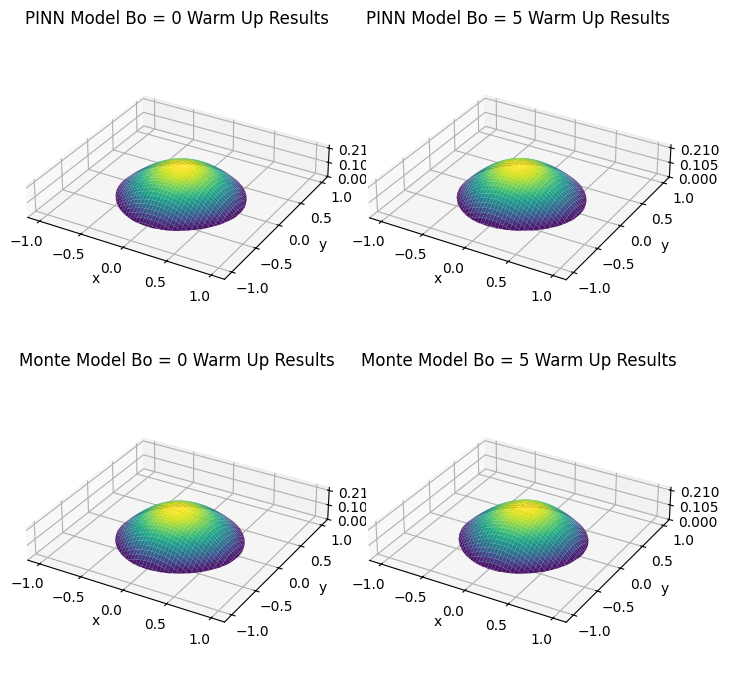

In [ ]:
## For visualization purposes, we'll use 640 grid points instead of the 160 grid points used
## during training.
num_grids = 640

## Obtain the predicted z-profiles from the standard PINN models.
pinn_pred1 = pinn1.predict(utils.get_coords(pinn1.space_width, num_grids), batch_size = num_grids ** 2, verbose = 0)
pinn_pred2 = pinn2.predict(utils.get_coords(pinn2.space_width, num_grids), batch_size = num_grids ** 2, verbose = 0)

## Obtain the predicted z-profiles from the Monte-Carlo PINN models.
monte_pred1 = monte1.predict(utils.get_coords(monte1.space_width, num_grids), batch_size = num_grids ** 2, verbose = 0)
monte_pred2 = monte2.predict(utils.get_coords(monte2.space_width, num_grids), batch_size = num_grids ** 2, verbose = 0)

fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (7, 7), subplot_kw = {'projection': '3d'})
viz.plot_droplet(ax[0][0], pinn_pred1, pinn1.space_width, num_grids,
             plot_title = "PINN Model Bo = 0 Warm Up Results", x_label = "x", y_label = "y")
viz.plot_droplet(ax[0][1], pinn_pred2, pinn2.space_width, num_grids,
             plot_title = "PINN Model Bo = 5 Warm Up Results", x_label = "x", y_label = "y")
viz.plot_droplet(ax[1][0], monte_pred1, monte1.space_width, num_grids,
             plot_title = "Monte Model Bo = 0 Warm Up Results", x_label = "x", y_label = "y")
viz.plot_droplet(ax[1][1], monte_pred2, monte2.space_width, num_grids,
             plot_title = "Monte Model Bo = 5 Warm Up Results", x_label = "x", y_label = "y")
fig.tight_layout()
plt.show()

## Training:
The following cell trains the four PINN models separately. If the target Bond number is greater than zero, the model will have to train a few epochs at smaller Bond numbers for stable convergence. Users can speciy how many steps the model needs to reach its target Bond number by addressing the ``Bo_steps`` parameter, and how many epochs to train for each step using the ``per_Bo_step`` variable. The ``final_Bo_step`` parameter allows the user to specify the number of epochs at the target Bond number step.

We found that 5000 epochs per step, and 15000 epochs at the final step results in the best balance of performance and speed of the training session.

Training Epoch: 14999 / 15000 |  Bond Number: 0.000  |  PDE Loss: 0.003
Training Epoch: 39999 / 40000 |  Bond Number: 5.000  |  PDE Loss: 0.008
Training Epoch: 14999 / 15000 |  Bond Number: 0.000  |  PDE Loss: 0.033
Training Epoch: 4999 / 40000 |  Bond Number: 0.000  |  PDE Loss: 0.304


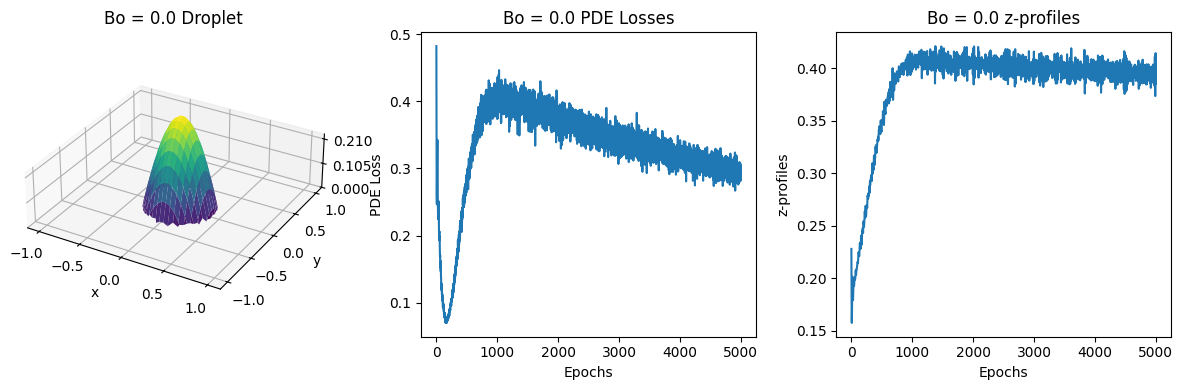

Training Epoch: 9999 / 40000 |  Bond Number: 1.000  |  PDE Loss: 0.398


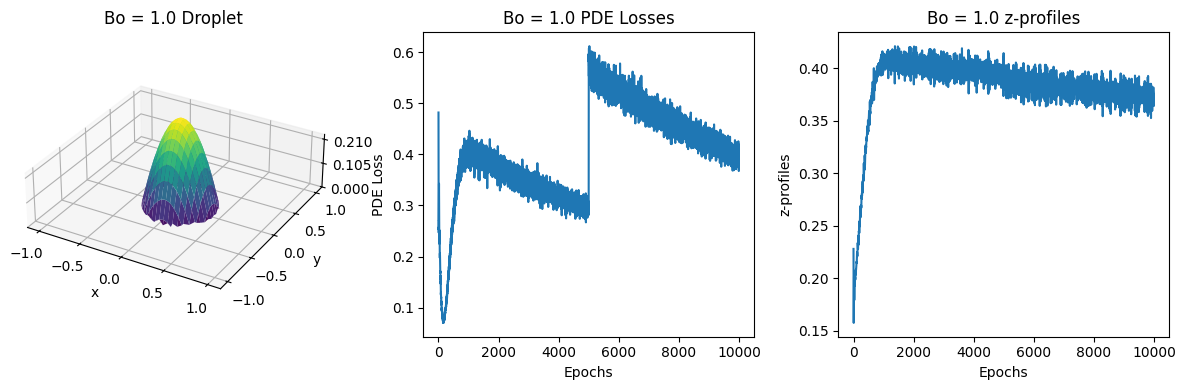

Training Epoch: 14999 / 40000 |  Bond Number: 2.000  |  PDE Loss: 0.238


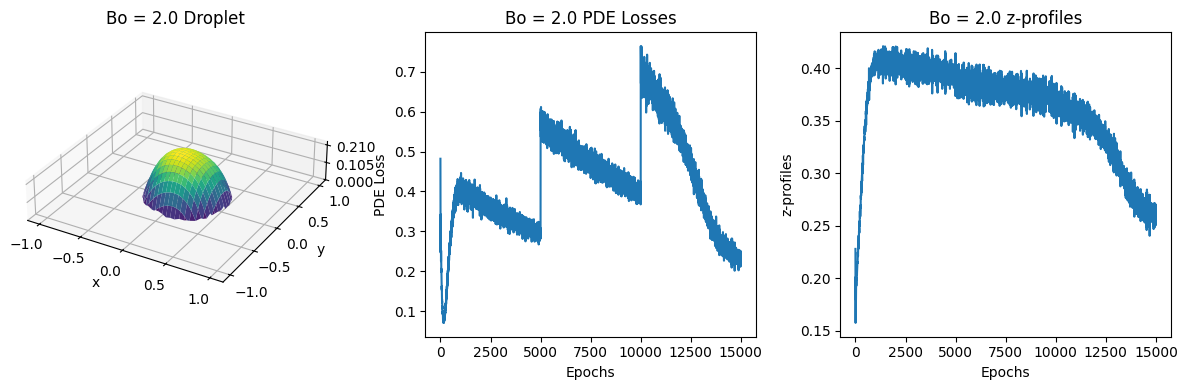

Training Epoch: 19999 / 40000 |  Bond Number: 3.000  |  PDE Loss: 0.189


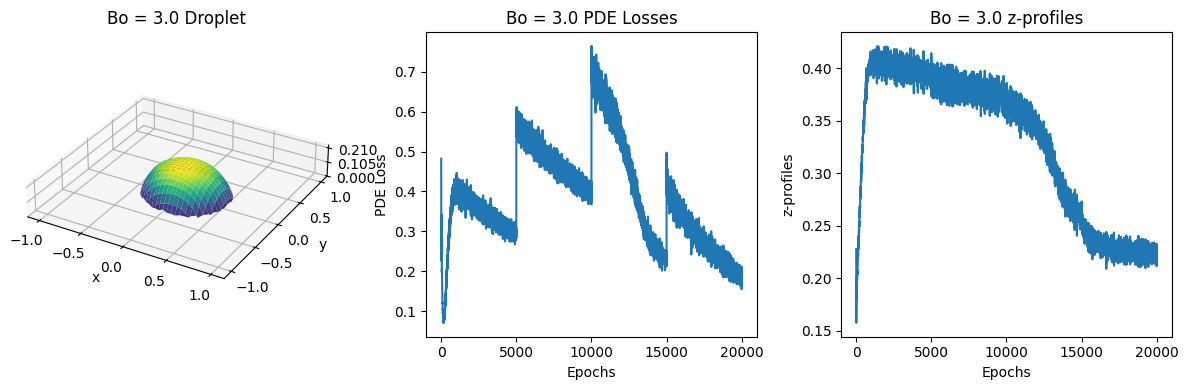

Training Epoch: 24999 / 40000 |  Bond Number: 4.000  |  PDE Loss: 0.136


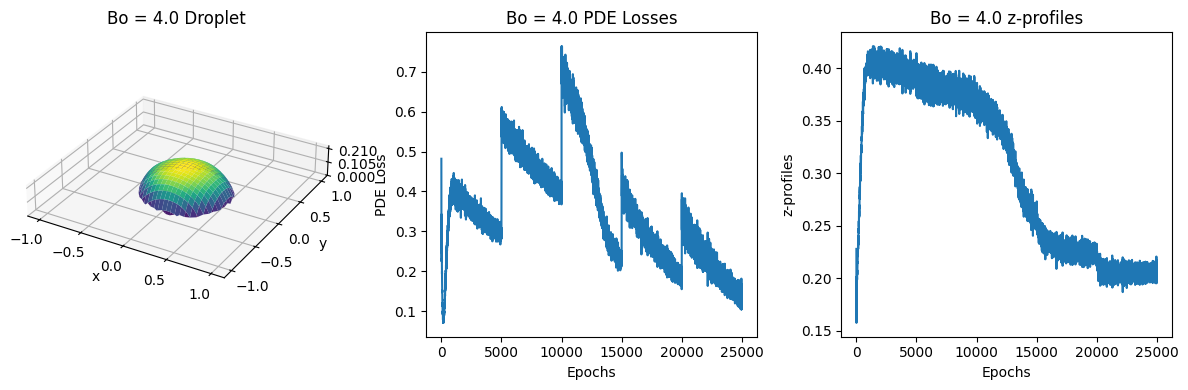

Training Epoch: 39999 / 40000 |  Bond Number: 5.000  |  PDE Loss: 0.031


In [ ]:
## Train the standard PINN models at Bond numbers 0 and 5.
train_pinn(pinn1, Bo_steps = 0, per_Bo_step = 0, final_Bo_step = 15000)
train_pinn(pinn2, Bo_steps = 5, per_Bo_step = 5000, final_Bo_step = 15000)

## Train the Monte-Carlo PINN models at Bond numbers 0 and 5.
## Visualize the Monte-Carlo PINN model at Bond number 5.
train_pinn(monte1, Bo_steps = 0, per_Bo_step = 0, final_Bo_step = 15000, use_monte = True)
train_pinn(monte2, Bo_steps = 5, per_Bo_step = 5000, final_Bo_step = 15000, use_monte = True, show_visual = True)

## Results:
Below shows a 3D visualization of the training results as well as the 2D slices of each model's predictions.

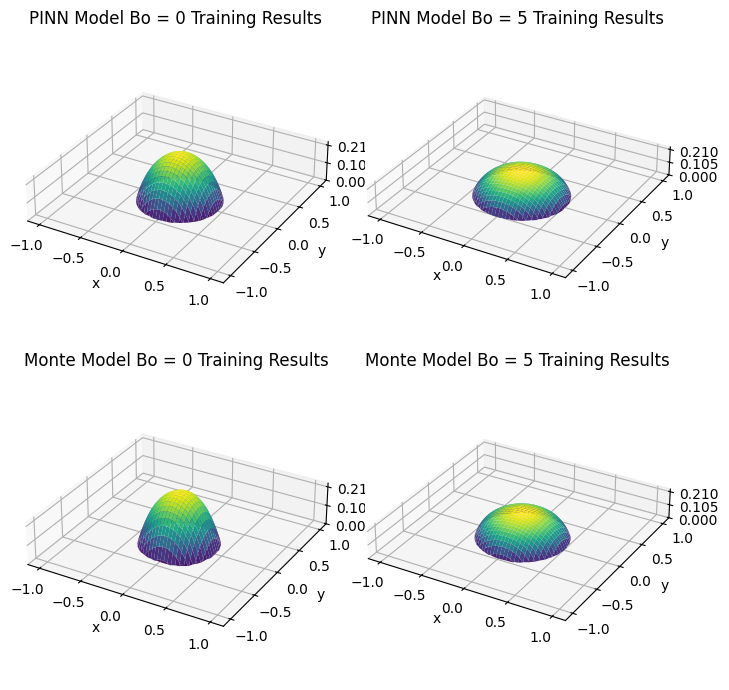

In [ ]:
## Obtain the z-profile predictions for all the models.
pinn_pred1 = pinn1.predict(utils.get_coords(pinn1.space_width, num_grids), batch_size = num_grids ** 2, verbose = 0)
pinn_pred2 = pinn2.predict(utils.get_coords(pinn2.space_width, num_grids), batch_size = num_grids ** 2, verbose = 0)
monte_pred1 = monte1.predict(utils.get_coords(monte1.space_width, num_grids), batch_size = num_grids ** 2, verbose = 0)
monte_pred2 = monte2.predict(utils.get_coords(monte2.space_width, num_grids), batch_size = num_grids ** 2, verbose = 0)

fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (7, 7), subplot_kw = {'projection': '3d'})
viz.plot_droplet(ax[0][0], pinn_pred1, pinn1.space_width, num_grids,
             plot_title = "PINN Model Bo = 0 Training Results", x_label = "x", y_label = "y")
viz.plot_droplet(ax[0][1], pinn_pred2, pinn2.space_width, num_grids,
             plot_title = "PINN Model Bo = 5 Training Results", x_label = "x", y_label = "y")
viz.plot_droplet(ax[1][0], monte_pred1, monte1.space_width, num_grids,
             plot_title = "Monte Model Bo = 0 Training Results", x_label = "x", y_label = "y")
viz.plot_droplet(ax[1][1], monte_pred2, monte2.space_width, num_grids,
             plot_title = "Monte Model Bo = 5 Training Results", x_label = "x", y_label = "y")
fig.tight_layout()
plt.show()

2D Views of Standard PINN Bond Number 0 and 5


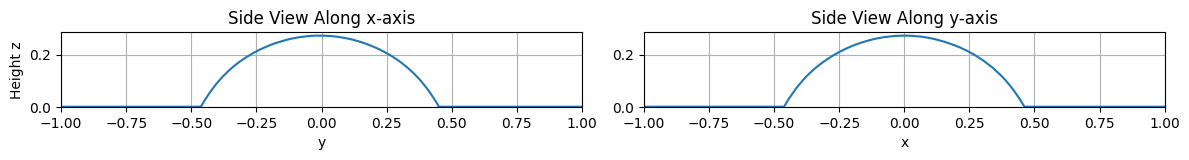

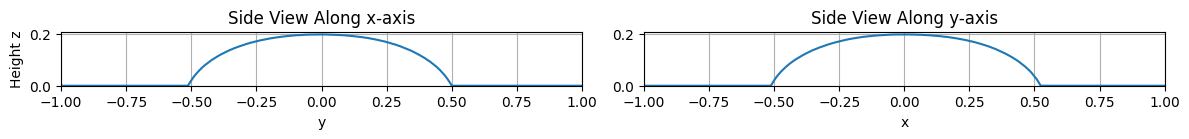

2D Views of Monte-Carlo PINN Bond Number 0 and 5


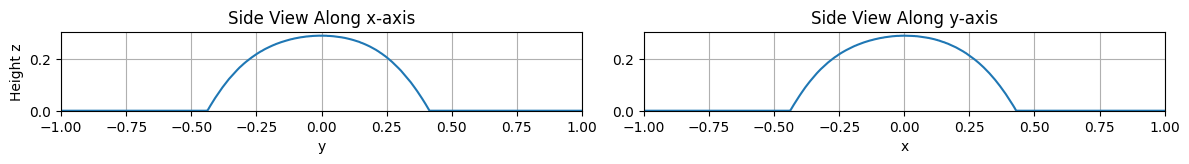

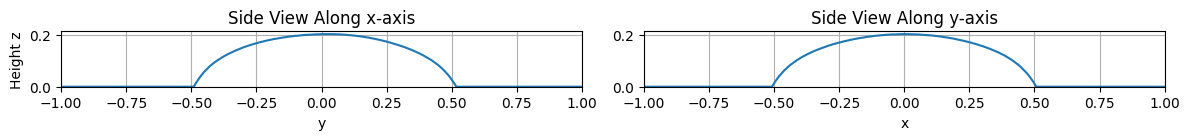

In [18]:
print("2D Views of Standard PINN Bond Number 0 and 5")
viz.plot_yz_xz_views(pinn_pred1, pinn1.space_width, num_grids)
viz.plot_yz_xz_views(pinn_pred2, pinn2.space_width, num_grids)

print("2D Views of Monte-Carlo PINN Bond Number 0 and 5")
viz.plot_yz_xz_views(monte_pred1, monte1.space_width, num_grids)
viz.plot_yz_xz_views(monte_pred2, monte2.space_width, num_grids)